<a href="https://colab.research.google.com/github/Jess-chege/Datascience-practice/blob/main/Compare_KNN%2C_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing all the needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#importing the models for the notebook
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC


### Assignment 3: Classifier Comparison Study
Objective: Compare KNN, SVM, and Naive Bayes classifiers on the same dataset to understand their strengths and weaknesses.

Dataset: Assignment-Dataset/assignment3_classifier_comparison.csv

Context: A company wants to classify customer segments into three categories (Class_A, Class_B, Class_C) based on their behavioral metrics.


Import necessary libraries
Load and preprocess the dataset
Perform comprehensive EDA including:
Feature distributions
Class distribution
Feature correlations
Pairwise scatter plots
Separate features (Feature_A, Feature_B, Feature_C, Feature_D) and target (Target_Class)
Handle categorical feature (Categorical_Feature) - encode appropriately
Encode the target variable (Class_A, Class_B, Class_C)
Split the data into training (80%) and test (20%) sets with random_state=42
Apply feature scaling using StandardScaler
Implement and evaluate three classifiers:
KNN (with optimal K from testing K=3, 5, 7)
SVM (with RBF kernel)
Gaussian Naive Bayes
Compare all classifiers using:
Accuracy
Confusion matrices
Classification reports (precision, recall, f1-score for each class)
Determine the best classifier for this multi-class problem
Expected Deliverables:
Comprehensive EDA visualizations
Summary table comparing all classifiers
Individual confusion matrices for each classifier
Classification reports for each classifier
Discussion on which classifier works best and why
Recommendations for which classifier to use in production

In [ ]:
#importing the dataset
data = pd.read_csv('/content/drive/MyDrive/assignment3_classifier_comparison.csv')
data.head(10)

,Sample_ID,Feature_A,Feature_B,Feature_C,Feature_D,Categorical_Feature,Target_Class
0,1,25,45,68,82,Type_1,Class_A
1,2,78,32,15,28,Type_2,Class_B
2,3,92,88,75,90,Type_3,Class_C
3,4,18,52,72,78,Type_1,Class_A
4,5,65,28,22,35,Type_2,Class_B
5,6,88,92,82,95,Type_3,Class_C
6,7,22,48,65,75,Type_1,Class_A
7,8,72,35,18,30,Type_2,Class_B
8,9,95,85,78,88,Type_3,Class_C
9,10,15,55,70,80,Type_1,Class_A


In [ ]:
#checking data information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Sample_ID            350 non-null    int64 
 1   Feature_A            350 non-null    int64 
 2   Feature_B            350 non-null    int64 
 3   Feature_C            350 non-null    int64 
 4   Feature_D            350 non-null    int64 
 5   Categorical_Feature  350 non-null    object
 6   Target_Class         350 non-null    object
dtypes: int64(5), object(2)
memory usage: 19.3+ KB


In [ ]:
#checking the data statistical summary
data.describe()

,Sample_ID,Feature_A,Feature_B,Feature_C,Feature_D
count,350.000000,350.000000,350.000000,350.000000,350.000000
mean,175.500000,55.274286,56.005714,54.437143,65.622857
std,101.180532,29.295240,26.663347,27.604457,28.123765
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,88.250000,30.500000,38.000000,30.000000,42.750000
50%,175.500000,58.000000,55.000000,62.000000,75.000000
75%,262.750000,81.500000,80.000000,78.000000,88.000000
max,350.000000,100.000000,100.000000,100.000000,100.000000


In [ ]:
#Checking for null values
data.isna().sum()

,0
Sample_ID,0
Feature_A,0
Feature_B,0
Feature_C,0
Feature_D,0
Categorical_Feature,0
Target_Class,0


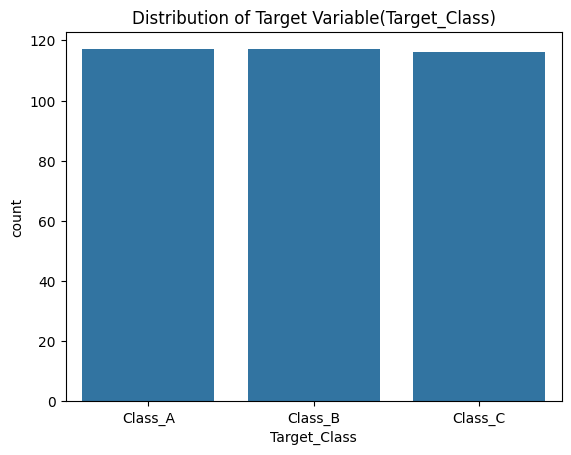

In [ ]:
#visualizing the data to gain a more understanding of the features and how they relate
# Visualize target distribution
sns.countplot(x='Target_Class', data=data)
plt.title("Distribution of Target Variable(Target_Class)")
plt.show()

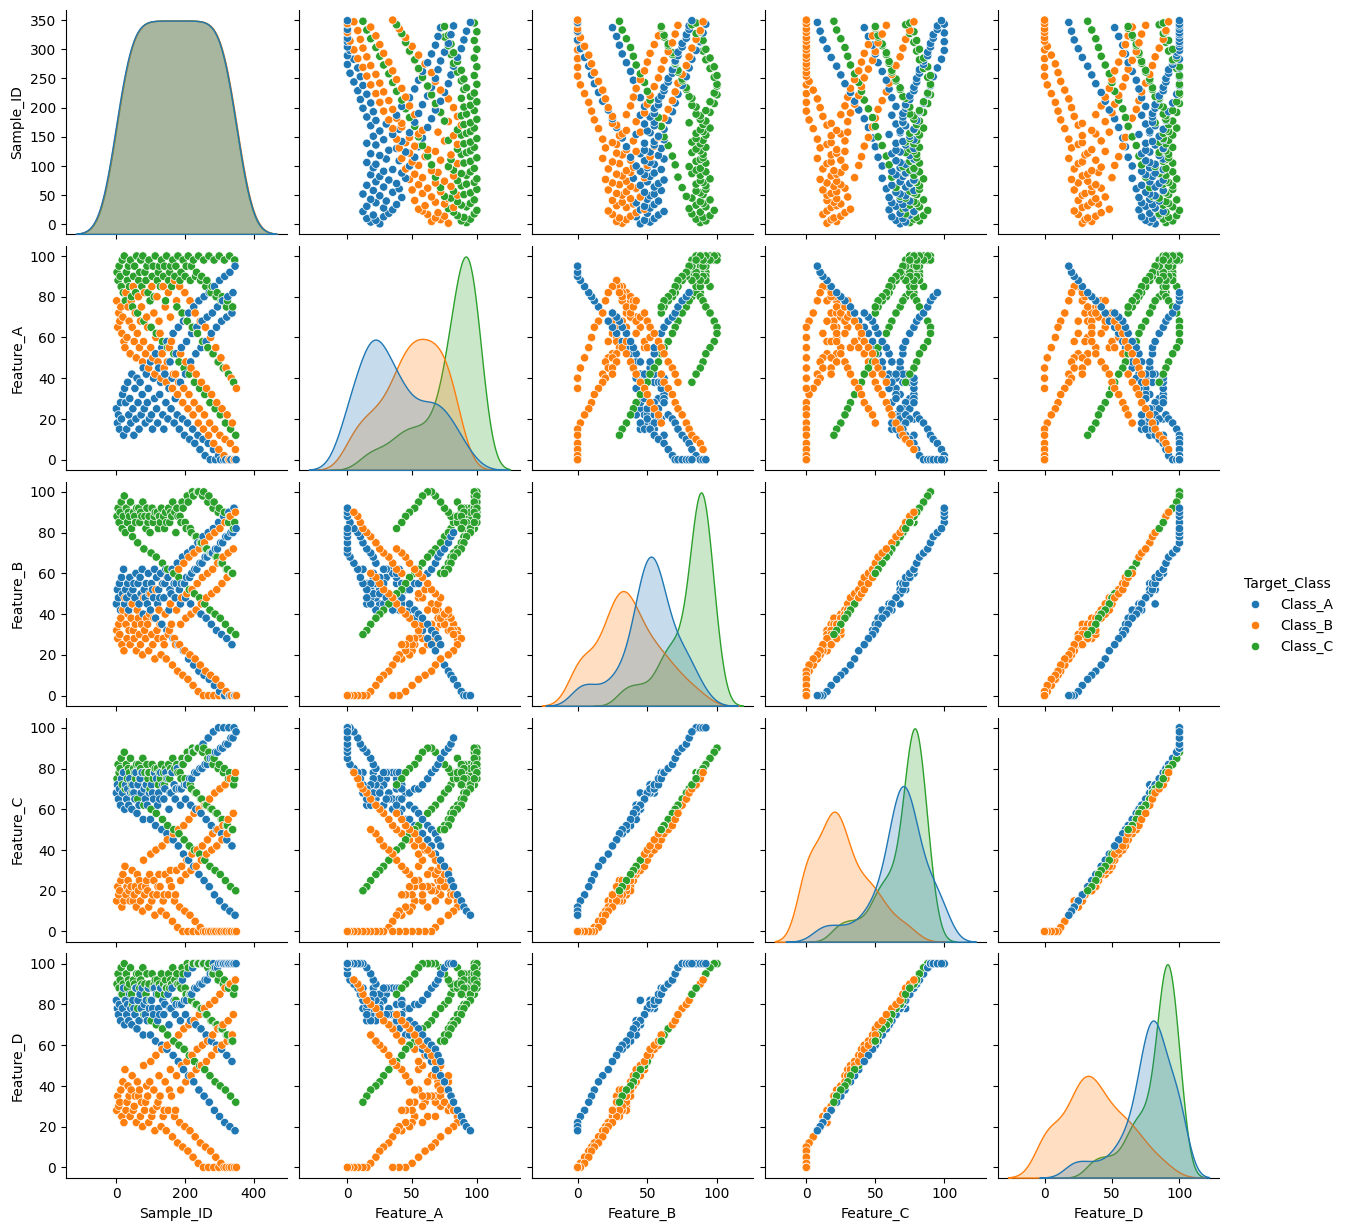

In [ ]:
# Pairplot with target
sns.pairplot(data, hue='Target_Class')
plt.show()

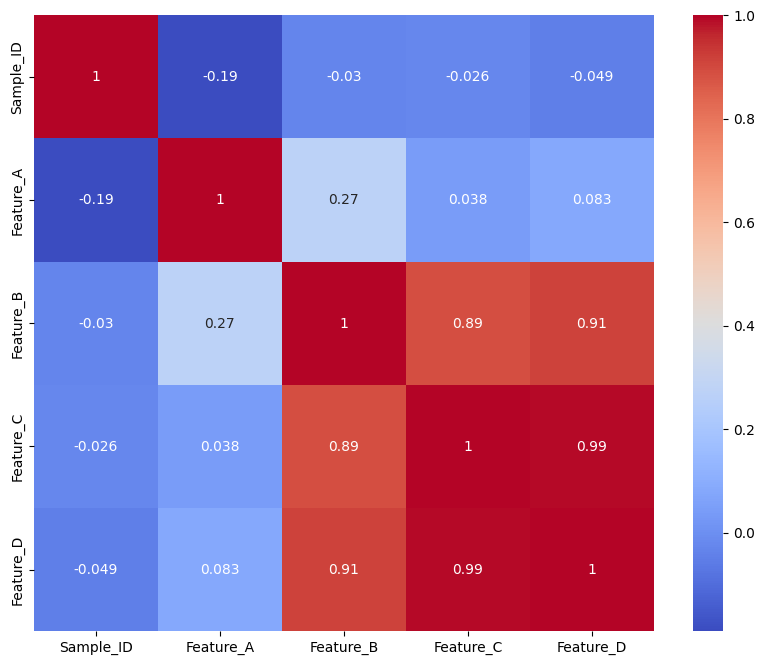

In [ ]:
# Correlation heatmap using only numerical data
plt.figure(figsize=(10,8))
sns.heatmap(data.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
# Handling categorical features
if 'Categorical_Feature' in data.columns:
    data = pd.get_dummies(data, columns=['Categorical_Feature'], drop_first=True)

# Encoding the target variable
le = LabelEncoder()
data['Target_Class'] = le.fit_transform(data['Target_Class'])

# Separating the features and target
X = data.drop('Target_Class', axis=1)
y = data['Target_Class']

In [ ]:
#splitting the data
X_train, X_test, y_train, y_test =train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
#standardizing the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#training the knn model with many different ks and calculating the metrics
knn_results = {}
for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    knn_results[k] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'conf_matrix': confusion_matrix(y_test, y_pred),
        'report': classification_report(y_test, y_pred)
    }

# Selecting K with highest accuracy
best_k = max(knn_results, key=lambda k: knn_results[k]['accuracy'])
print(f"Optimal K: {best_k}")


Optimal K: 3


In [ ]:
#svm using the rbf kernel
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

svm_results = {
    'accuracy': accuracy_score(y_test, y_pred_svm),
    'conf_matrix': confusion_matrix(y_test, y_pred_svm),
    'report': classification_report(y_test, y_pred_svm)
}


In [ ]:
#training the gaussianNaive bayes
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

gnb_results = {
    'accuracy': accuracy_score(y_test, y_pred_gnb),
    'conf_matrix': confusion_matrix(y_test, y_pred_gnb),
    'report': classification_report(y_test, y_pred_gnb)
}

In [ ]:
#comparing the classifiers (the three models)
comparison = pd.DataFrame({
    'Classifier': ['KNN', 'SVM', 'GaussianNB'],
    'Accuracy': [knn_results[best_k]['accuracy'], svm_results['accuracy'], gnb_results['accuracy']]
})

print(comparison)


   Classifier  Accuracy
0         KNN       1.0
1         SVM       1.0
2  GaussianNB       1.0


In [ ]:
#printing the confusion matrix for comparison
print("KNN Confusion Matrix:\n", knn_results[best_k]['conf_matrix'])
print("SVM Confusion Matrix:\n", svm_results['conf_matrix'])
print("Naive Bayes Confusion Matrix:\n", gnb_results['conf_matrix'])

KNN Confusion Matrix:
 [[30  0  0]
 [ 0 19  0]
 [ 0  0 21]]
SVM Confusion Matrix:
 [[30  0  0]
 [ 0 19  0]
 [ 0  0 21]]
Naive Bayes Confusion Matrix:
 [[30  0  0]
 [ 0 19  0]
 [ 0  0 21]]


In [ ]:
#printing the model reports
print("KNN Report:\n", knn_results[best_k]['report'])
print("SVM Report:\n", svm_results['report'])
print("Naive Bayes Report:\n", gnb_results['report'])

KNN Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        19
           2       1.00      1.00      1.00        21

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70

SVM Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        19
           2       1.00      1.00      1.00        21

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70

Naive Bayes Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        19
           2       1.00     

### observations

All three classifiers-KNN, SVM (RBF), and Gaussian Naive Bayes-achieved perfect performance on the test set, with 100% accuracy, precision, recall, and F1-score across all classes. This indicates that the dataset is well-separated and easy to classify. Since all models perform equally well, the choice of classifier can be guided by other factors: Naive Bayes offers simplicity and speed, KNN provides intuitive reasoning based on local clusters, and SVM is robust for more complex future data. Overall, any of the three can be used in production,
but I'm  recommending the Naive Bayes because it has great efficiency.